In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.getcwd()

'/home/0d1e7974-5d19-419b-b7b6-676c4ccb4931/Project777'

In [6]:
os.listdir()

['Impact_of_Remote_Work_on_Mental_Health.csv',
 '.ipynb_checkpoints',
 'Untitled.ipynb']

In [2]:
df= pd.read_csv("Impact_of_Remote_Work_on_Mental_Health.csv")
df.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Employee_ID                        5000 non-null   object
 1   Age                                5000 non-null   int64 
 2   Gender                             5000 non-null   object
 3   Job_Role                           5000 non-null   object
 4   Industry                           5000 non-null   object
 5   Years_of_Experience                5000 non-null   int64 
 6   Work_Location                      5000 non-null   object
 7   Hours_Worked_Per_Week              5000 non-null   int64 
 8   Number_of_Virtual_Meetings         5000 non-null   int64 
 9   Work_Life_Balance_Rating           5000 non-null   int64 
 10  Stress_Level                       5000 non-null   object
 11  Mental_Health_Condition            3804 non-null   object
 12  Access

In [9]:
df.describe()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


In [10]:
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")

Employee_ID: ['EMP0001' 'EMP0002' 'EMP0003' 'EMP0004' 'EMP0005' 'EMP0006' 'EMP0007'
 'EMP0008' 'EMP0009' 'EMP0010']
Age: [32 40 59 27 49 31 42 56 30 33]
Gender: ['Non-binary' 'Female' 'Male' 'Prefer not to say']
Job_Role: ['HR' 'Data Scientist' 'Software Engineer' 'Sales' 'Marketing' 'Designer'
 'Project Manager']
Industry: ['Healthcare' 'IT' 'Education' 'Finance' 'Consulting' 'Manufacturing'
 'Retail']
Years_of_Experience: [13  3 22 20 32 31 24  6  9 28]
Work_Location: ['Hybrid' 'Remote' 'Onsite']
Hours_Worked_Per_Week: [47 52 46 32 35 39 51 54 24 57]
Number_of_Virtual_Meetings: [ 7  4 11  8 12  3  6 13  9  1]
Work_Life_Balance_Rating: [2 1 5 4 3]
Stress_Level: ['Medium' 'High' 'Low']
Mental_Health_Condition: ['Depression' 'Anxiety' nan 'Burnout']
Access_to_Mental_Health_Resources: ['No' 'Yes']
Productivity_Change: ['Decrease' 'Increase' 'No Change']
Social_Isolation_Rating: [1 3 4 5 2]
Satisfaction_with_Remote_Work: ['Unsatisfied' 'Satisfied' 'Neutral']
Company_Support_for_Remote_Wor

In [12]:
df.isnull().sum()

Employee_ID                             0
Age                                     0
Gender                                  0
Job_Role                                0
Industry                                0
Years_of_Experience                     0
Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
Region                                  0
dtype: int64

In [13]:
df= df.dropna()

In [3]:
stress_map= {'Low':1,'Medium':2,'High':3}
df['stress_score']= df['Stress_Level'].map(stress_map)

sat_map = {'Low':1,'Medium':2,'High':3}
df['satisfaction_score'] = df['Satisfaction_with_Remote_Work'].map(sat_map)

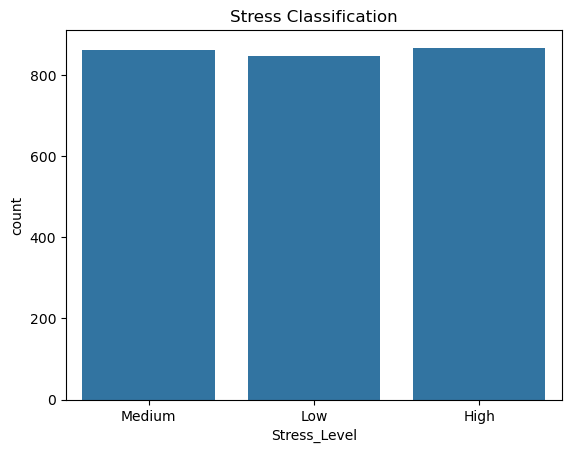

In [17]:
sns.countplot(data=df,x='Stress_Level')
plt.title("Stress Classification")
plt.show()

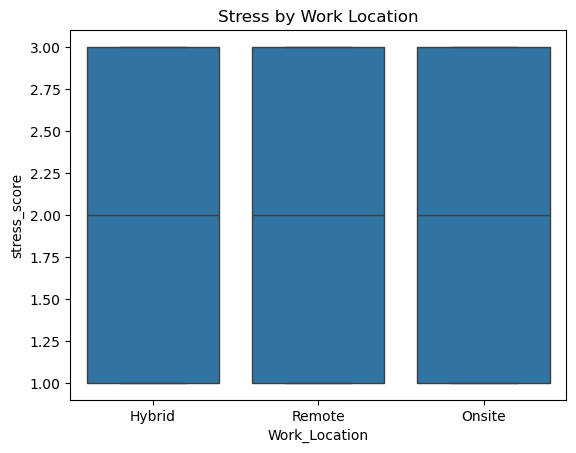

In [18]:
sns.boxplot(data=df,x='Work_Location',y='stress_score')
plt.title("Stress by Work Location")
plt.show()

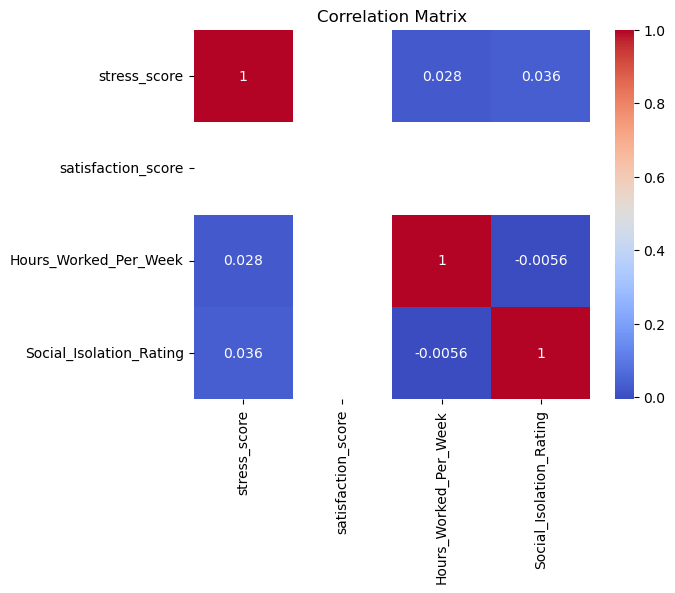

In [21]:
numeric_cols=['stress_score','satisfaction_score','Hours_Worked_Per_Week','Social_Isolation_Rating']
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
fake_happy = df[(df['stress_score'] == 3) & (df['satisfaction_score'] >= 2)]

fake_happy['Job_Role'].value_counts()

Series([], Name: count, dtype: int64)

In [6]:
df['risk_score'] = (
    df['stress_score'] * 0.5 +
    df['Social_Isolation_Rating'] * 0.3 +
    df['Hours_Worked_Per_Week'] * 0.02
)

df['risk_percentile'] = pd.qcut(df['risk_score'], 10, labels=False)

high_risk = df[df['risk_percentile'] == 9]

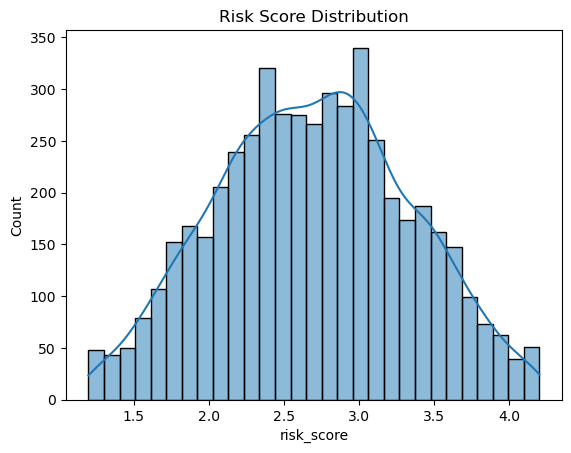

In [7]:
sns.histplot(df['risk_score'], kde=True)
plt.title("Risk Score Distribution")
plt.show()

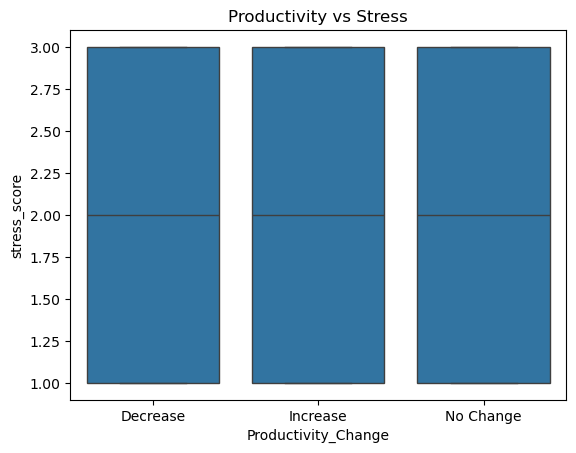

In [8]:
sns.boxplot(x='Productivity_Change', y='stress_score', data=df)
plt.title("Productivity vs Stress")
plt.show()

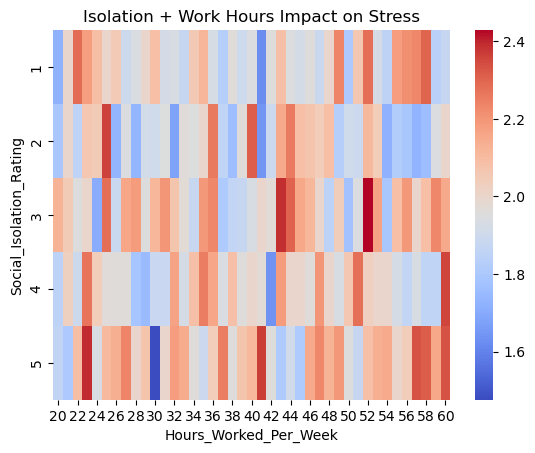

In [9]:
pivot = df.pivot_table(values='stress_score',
                       index='Social_Isolation_Rating',
                       columns='Hours_Worked_Per_Week',
                       aggfunc='mean')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Isolation + Work Hours Impact on Stress")
plt.show()

In [ ]:
## 💡 Key Insights

- Isolation combined with long working hours significantly increases stress
- High productivity does not guarantee good mental health
- Some employees appear satisfied but are actually highly stressed (hidden risk)
- Stress is influenced by multiple factors, not a single variable
- A small group of employees represents the highest risk segment

In [ ]:
## 📌 Conclusion

This analysis reveals that remote work impacts employees differently.
Organizations should adopt personalized strategies instead of a one-size-fits-all approach.

Data-driven decisions can significantly improve employee well-being and productivity.